<a href="https://colab.research.google.com/github/EvelynRobert/US-Accident-Modeling-DS4420/blob/main/TimeSeries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Proof Of Concept - US Accident Modeling**

This proof of concept demonstrates the viability of our two-model approach
applied to a 10,000-row random sample drawn from the full US Accidents dataset
(7.7 million records, 2016–2023).

### Data Preparation
The sampled data was cleaned by selecting relevant features, dropping rows with
missing critical values, imputing missing numeric fields with column medians,
and parsing timestamps to extract temporal features (date, hour, day of week,
month, year).

### Model 1: Time Series Analysis
Accident records are aggregated into daily frequency counts and modeled over
time to capture seasonal patterns, weekly cycles, and long-term trends in
accident rates across the 7-year dataset span — including the notable disruption
caused by COVID-19 in 2020.

### Model 2: Bayesian Classification (Coming Soon)
A Bayesian classification model will be implemented in R to predict accident
severity (1–4) from environmental and situational features such as weather
conditions, time of day, and visibility. This probabilistic approach will
quantify uncertainty in predictions and identify the most significant
contributing factors to severe accidents.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/accidents_sample.csv')

In [4]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-7197653,Source1,2,2020-04-25 17:48:08,2020-04-25 18:18:08,26.057030,-80.162350,26.057030,-80.162350,0.000,...,False,False,False,False,False,False,Day,Day,Day,Day
1,A-5561198,Source1,2,2021-03-29 23:34:00,2021-03-30 00:17:00,40.689870,-74.269971,40.695705,-74.259646,0.675,...,False,False,False,False,False,False,Night,Night,Night,Night
2,A-7725214,Source1,3,2019-05-20 16:33:45,2019-05-20 17:02:02,40.730990,-74.049260,40.730880,-74.047990,0.067,...,False,False,False,False,False,False,Day,Day,Day,Day
3,A-5474868,Source1,2,2021-07-02 22:39:00,2021-07-02 23:57:28,36.958928,-120.019528,36.963575,-120.019565,0.321,...,False,False,False,False,False,False,Night,Night,Night,Night
4,A-5365556,Source1,2,2022-04-11 15:30:22.000000000,2022-04-11 16:45:22.000000000,29.738196,-95.441665,29.738190,-95.442547,0.053,...,False,False,False,False,True,False,Day,Day,Day,Day


In [5]:
df.info()
df.describe()
df.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     10000 non-null  object 
 1   Source                 10000 non-null  object 
 2   Severity               10000 non-null  int64  
 3   Start_Time             10000 non-null  object 
 4   End_Time               10000 non-null  object 
 5   Start_Lat              10000 non-null  float64
 6   Start_Lng              10000 non-null  float64
 7   End_Lat                5587 non-null   float64
 8   End_Lng                5587 non-null   float64
 9   Distance(mi)           10000 non-null  float64
 10  Description            10000 non-null  object 
 11  Street                 9979 non-null   object 
 12  City                   10000 non-null  object 
 13  County                 10000 non-null  object 
 14  State                  10000 non-null  object 
 15  Zip

,0
End_Lng,4413
End_Lat,4413
Precipitation(in),2774
Wind_Chill(F),2557
Wind_Speed(mph),750
Wind_Direction,229
Visibility(mi),216
Humidity(%),215
Weather_Condition,210
Temperature(F),198


In [6]:
cols_to_keep = [
    'Start_Time', 'Severity', 'Temperature(F)',
    'Humidity(%)', 'Visibility(mi)', 'Weather_Condition',
    'Sunrise_Sunset', 'State', 'Distance(mi)'
]
df = df[cols_to_keep].copy()

In [7]:
# Drop rows missing critical columns
df.dropna(subset=['Start_Time', 'Severity'], inplace=True)

# Fill numeric columns with median
num_cols = ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Distance(mi)']
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical with mode
df['Weather_Condition'] = df['Weather_Condition'].fillna(df['Weather_Condition'].mode()[0])
df['Sunrise_Sunset'] = df['Sunrise_Sunset'].fillna(df['Sunrise_Sunset'].mode()[0])

In [8]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')
df['Date'] = df['Start_Time'].dt.date
df['Year'] = df['Start_Time'].dt.year
df['Month'] = df['Start_Time'].dt.month
df['Hour'] = df['Start_Time'].dt.hour
df['DayOfWeek'] = df['Start_Time'].dt.dayofweek

In [9]:
df.head()
df.info()
df.describe()
df.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Start_Time         10000 non-null  datetime64[ns]
 1   Severity           10000 non-null  int64         
 2   Temperature(F)     10000 non-null  float64       
 3   Humidity(%)        10000 non-null  float64       
 4   Visibility(mi)     10000 non-null  float64       
 5   Weather_Condition  10000 non-null  object        
 6   Sunrise_Sunset     10000 non-null  object        
 7   State              10000 non-null  object        
 8   Distance(mi)       10000 non-null  float64       
 9   Date               10000 non-null  object        
 10  Year               10000 non-null  int32         
 11  Month              10000 non-null  int32         
 12  Hour               10000 non-null  int32         
 13  DayOfWeek          10000 non-null  int32         
dtypes: date

,0
Start_Time,0
Severity,0
Temperature(F),0
Humidity(%),0
Visibility(mi),0
Weather_Condition,0
Sunrise_Sunset,0
State,0
Distance(mi),0
Date,0


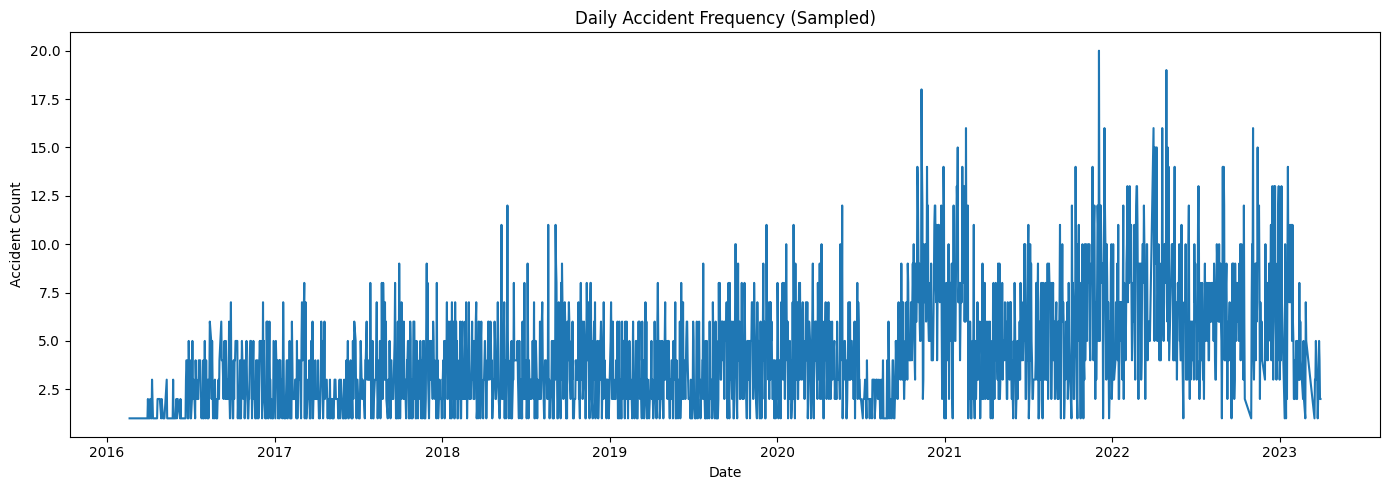

In [10]:
# Aggregate to daily accident counts
daily_counts = df.groupby('Date').size().reset_index(name='Accident_Count')
daily_counts['Date'] = pd.to_datetime(daily_counts['Date'])
daily_counts = daily_counts.sort_values('Date')

# Plot
plt.figure(figsize=(14, 5))
plt.plot(daily_counts['Date'], daily_counts['Accident_Count'])
plt.title('Daily Accident Frequency (Sampled)')
plt.xlabel('Date')
plt.ylabel('Accident Count')
plt.tight_layout()
plt.show()

- Clear upward trend: Accident frequency roughly doubles from 2016 to 2021-2023, reflecting both dataset growth (more API sources added over time) and real increases in traffic
- COVID-19 dip in 2020: Noticeable drop in early-mid 2020 followed by a sharp rebound, which is a meaningful real-world signal
- Increasing volatility post-2020: Spikes get taller and more frequent from 2021 onwards, suggesting more variable accident patterns in recent years
- Low counts in early 2016: this is expected since the dataset only starts collecting in February 2016 and coverage was sparse initially


 Since this is a sampled dataset, the count looks low but the temporal patterns are preserved.

In [11]:
# Simple rolling average as baseline
daily_counts['Rolling_7'] = daily_counts['Accident_Count'].rolling(window=7).mean()

# Train/test split
split = int(len(daily_counts) * 0.8)
train = daily_counts[:split]
test = daily_counts[split:]

print(f"Training on {len(train)} days, testing on {len(test)} days")

Training on 1795 days, testing on 449 days


In [12]:
df.to_csv('/content/accidents_sample_clean.csv', index=False)

In [13]:
daily_counts.to_csv('/content/daily_counts.csv', index=False)

## Model 1: Time Series Analysis — Manual OLS Decomposition

Daily accident counts are modelled as a sum of four interpretable components:

- **Trend** — quadratic growth over the 7-year span
- **Annual seasonality** — 3 Fourier harmonics (yearly cycle)
- **Weekly seasonality** — 3 Fourier harmonics (day-of-week cycle)
- **COVID-19 disruption** — indicator variable for the 2020 lockdown window

Fitted with Ordinary Least Squares (OLS) using only NumPy.

In [14]:

# ── Calendar day offset from first record (preserves real spacing between dates)
dates  = pd.to_datetime(daily_counts['Date'])
t_days = (dates - dates.iloc[0]).dt.days.values.astype(float)
t_norm = t_days / t_days.max()   # normalise to [0, 1] for numerical stability

n   = len(daily_counts)
dow = dates.dt.dayofweek.values   # 0=Monday … 6=Sunday

# ── Annual Fourier features — captures within-year seasonal cycles
# Each (sin, cos) pair = one harmonic; 3 harmonics = 6 columns
annual_feats = []
for k in range(1, 4):
    annual_feats.append(np.sin(2 * np.pi * k * t_days / 365.25))
    annual_feats.append(np.cos(2 * np.pi * k * t_days / 365.25))

# ── Weekly Fourier features — captures Mon-Sun recurring pattern
weekly_feats = []
for k in range(1, 4):
    weekly_feats.append(np.sin(2 * np.pi * k * dow / 7))
    weekly_feats.append(np.cos(2 * np.pi * k * dow / 7))

# ── COVID-19 flag: covers the US lockdown and initial recovery window
covid_start = pd.Timestamp('2020-03-01')
covid_end   = pd.Timestamp('2020-08-31')
covid_dummy = ((dates >= covid_start) & (dates <= covid_end)).astype(float).values

# ── Design matrix X  (16 columns total)
# [ intercept | lin_trend | quad_trend | 6 × annual | 6 × weekly | covid ]
X = np.column_stack([
    np.ones(n),        # intercept
    t_norm,            # linear trend
    t_norm ** 2,       # quadratic trend — captures long-run acceleration
    *annual_feats,     # 6 annual seasonality terms
    *weekly_feats,     # 6 weekly cycle terms
    covid_dummy        # COVID disruption indicator
])

y = daily_counts['Accident_Count'].values.astype(float)

# Index bookmarks for decomposition later
IDX_TREND  = slice(0, 3)
IDX_ANNUAL = slice(3, 9)
IDX_WEEKLY = slice(9, 15)
IDX_COVID  = 15

print(f"Design matrix : {X.shape[0]} days × {X.shape[1]} features")
print(f"COVID window  : {int(covid_dummy.sum())} days flagged  "
      f"({covid_start.date()} → {covid_end.date()})")

Design matrix : 2244 days × 16 features
COVID window  : 161 days flagged  (2020-03-01 → 2020-08-31)


In [15]:
# ── Train / test split (reuses the existing split index)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ── Solve β = argmin ||Xβ − y||²
# lstsq uses SVD internally — more stable than computing (X'X)⁻¹ directly
beta, _, _, _ = np.linalg.lstsq(X_train, y_train, rcond=None)

# ── Predictions
y_pred_train = X_train @ beta
y_pred_test  = X_test  @ beta
y_pred_all   = X       @ beta

# Print coefficients
col_names = (
    ['intercept', 'trend_lin', 'trend_quad']
    + [f'annual_{"sin" if i%2==0 else "cos"}{(i//2)+1}' for i in range(6)]
    + [f'weekly_{"sin" if i%2==0 else "cos"}{(i//2)+1}' for i in range(6)]
    + ['covid']
)
print("OLS coefficients")
print("-" * 32)
for name, b in zip(col_names, beta):
    print(f"  {name:<20} {b:+.4f}")

OLS coefficients
--------------------------------
  intercept            +2.1626
  trend_lin            +2.2314
  trend_quad           +3.0374
  annual_sin1          -0.5921
  annual_cos1          +0.2615
  annual_sin2          -0.0462
  annual_cos2          -0.1474
  annual_sin3          -0.0180
  annual_cos3          +0.1050
  weekly_sin1          +1.0988
  weekly_cos1          -0.3541
  weekly_sin2          +0.4093
  weekly_cos2          +0.5166
  weekly_sin3          -0.2130
  weekly_cos3          +0.1958
  covid                -0.6911


In [16]:
def mae(a, p):  return np.mean(np.abs(a - p))
def rmse(a, p): return np.sqrt(np.mean((a - p) ** 2))
def r2(a, p):   return 1 - np.sum((a - p)**2) / np.sum((a - a.mean())**2)

print("Train set")
print(f"  MAE  = {mae(y_train,  y_pred_train):.3f}  accidents/day")
print(f"  RMSE = {rmse(y_train, y_pred_train):.3f}  accidents/day")
print(f"  R²   = {r2(y_train,  y_pred_train):.4f}")
print()
print("Test set")
print(f"  MAE  = {mae(y_test,  y_pred_test):.3f}  accidents/day")
print(f"  RMSE = {rmse(y_test, y_pred_test):.3f}  accidents/day")
print(f"  R²   = {r2(y_test,  y_pred_test):.4f}")

Train set
  MAE  = 1.634  accidents/day
  RMSE = 2.118  accidents/day
  R²   = 0.3032

Test set
  MAE  = 2.519  accidents/day
  RMSE = 3.226  accidents/day
  R²   = 0.0618


In [17]:
# ── Reconstruct individual components from the fitted weights
# Each component = relevant X columns × their β values

trend_comp  = X[:, IDX_TREND]  @ beta[IDX_TREND]    # long-run growth
annual_comp = X[:, IDX_ANNUAL] @ beta[IDX_ANNUAL]   # yearly cycle
weekly_comp = X[:, IDX_WEEKLY] @ beta[IDX_WEEKLY]   # day-of-week cycle
covid_comp  = X[:, IDX_COVID]  * beta[IDX_COVID]    # COVID shock
residuals   = y - y_pred_all                         # unexplained variance

print("Component amplitudes")
print("-" * 45)
print(f"  Trend range        : {trend_comp.min():.2f} → {trend_comp.max():.2f}")
print(f"  Annual std (±)     : {annual_comp.std():.3f}")
print(f"  Weekly std (±)     : {weekly_comp.std():.3f}")
print(f"  COVID coefficient  : {beta[IDX_COVID]:+.3f} accidents/day")
print(f"  Residual std       : {residuals.std():.3f}")

Component amplitudes
---------------------------------------------
  Trend range        : 2.16 → 7.43
  Annual std (±)     : 0.478
  Weekly std (±)     : 0.909
  COVID coefficient  : -0.691 accidents/day
  Residual std       : 2.382


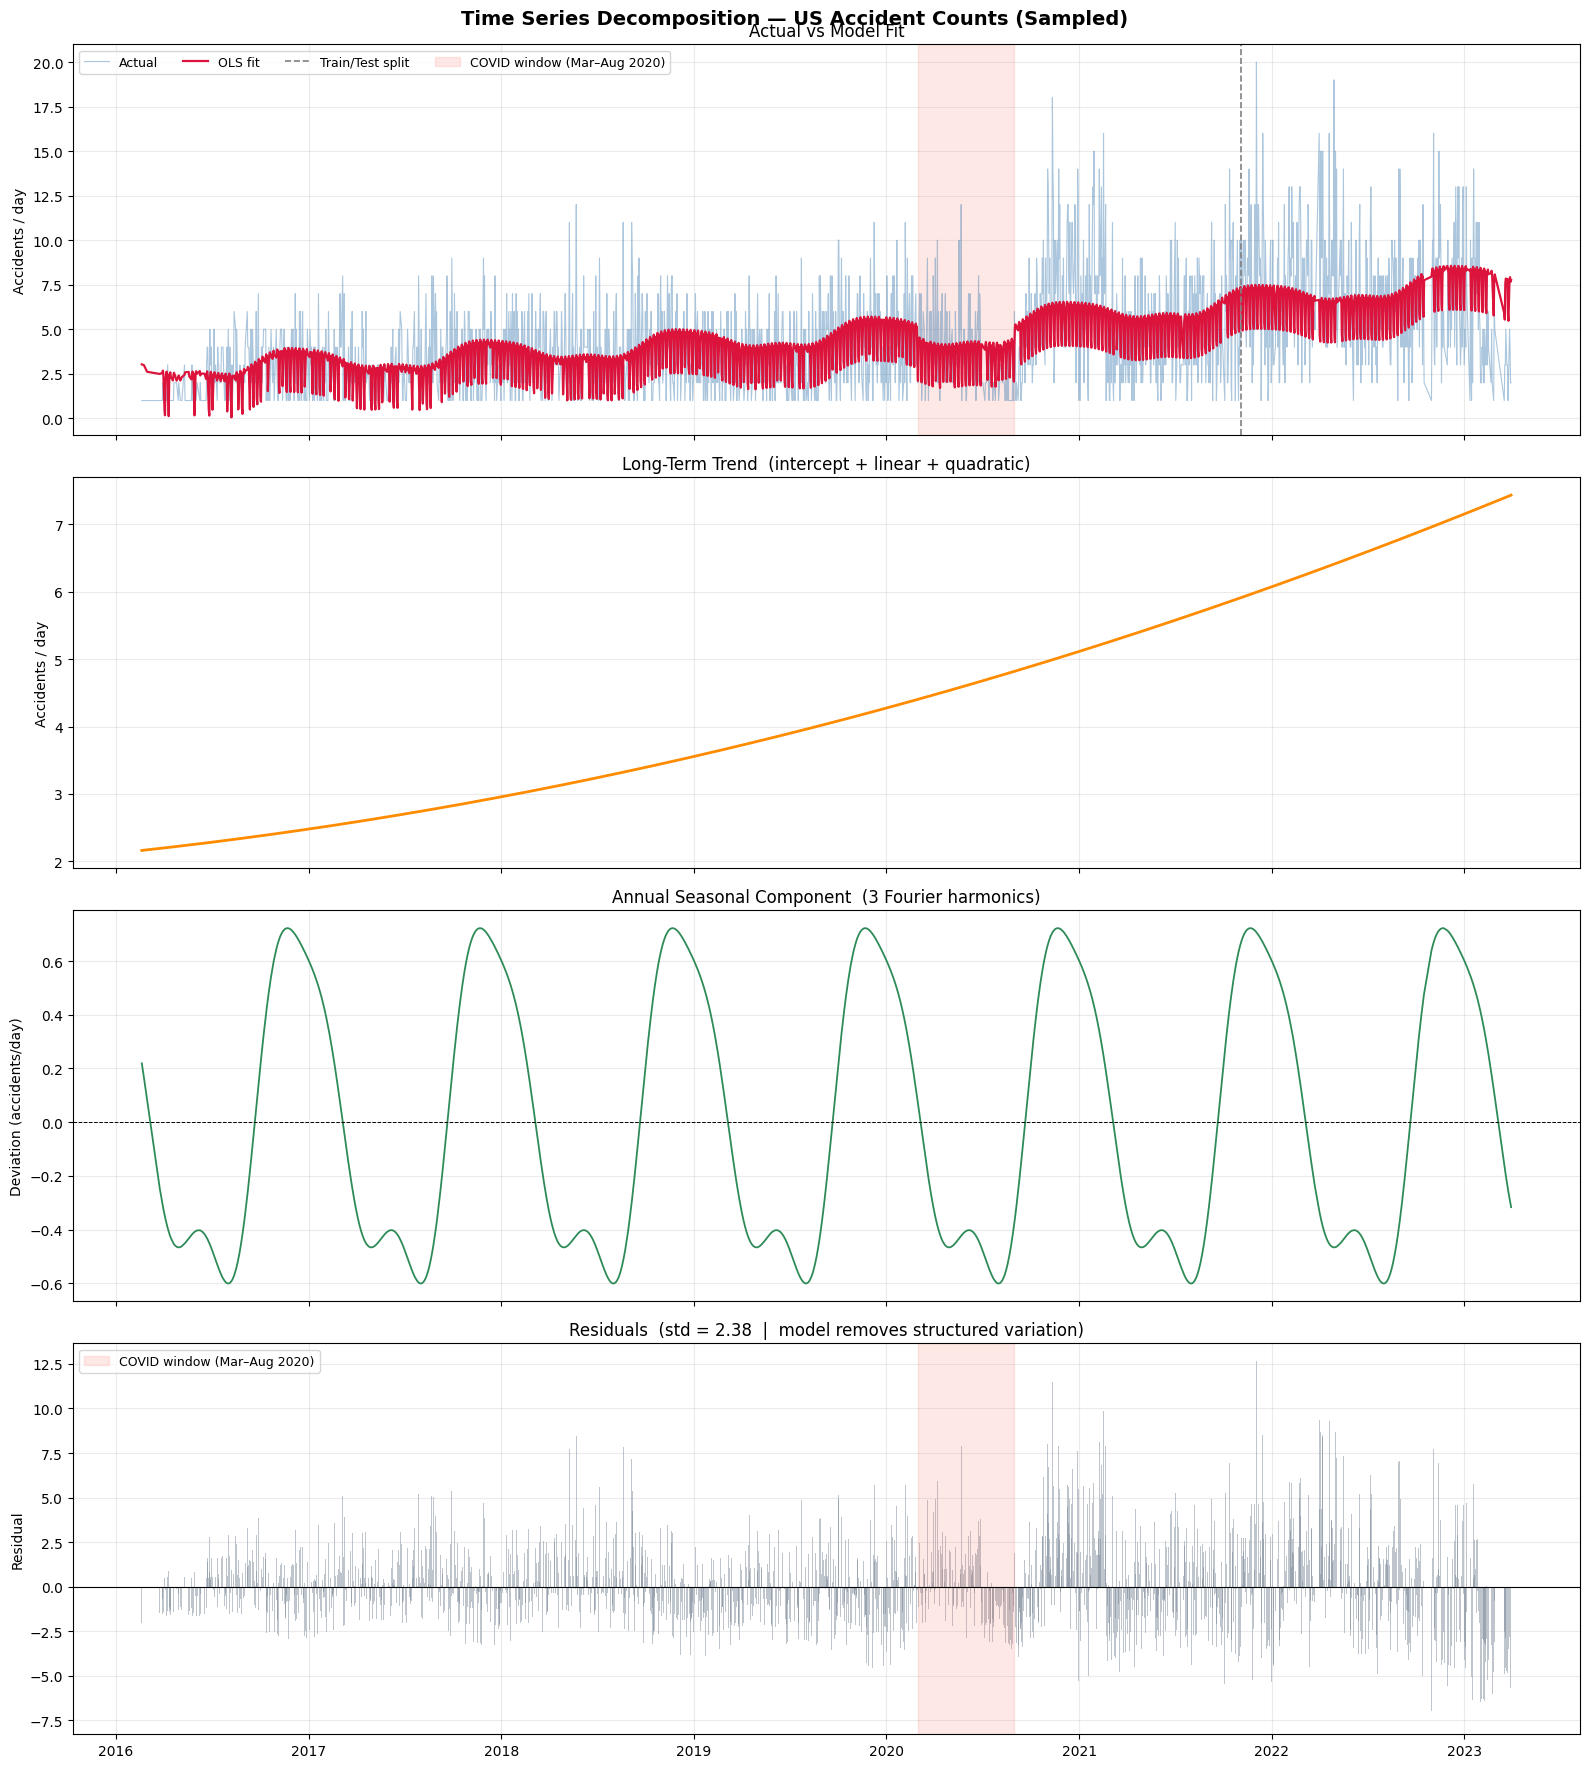

In [18]:
fig, axes = plt.subplots(4, 1, figsize=(16, 18), sharex=True)
fig.suptitle('Time Series Decomposition — US Accident Counts (Sampled)',
             fontsize=14, fontweight='bold')

split_date = dates.iloc[split]

def shade_covid(ax):
    ax.axvspan(covid_start, covid_end,
               color='salmon', alpha=0.18, label='COVID window (Mar–Aug 2020)')

# ── Panel 1: Actual vs Fitted
ax = axes[0]
ax.plot(dates, y,          color='steelblue', alpha=0.45, lw=0.8, label='Actual')
ax.plot(dates, y_pred_all, color='crimson',   lw=1.6,             label='OLS fit')
ax.axvline(split_date, color='gray', ls='--', lw=1.2,             label='Train/Test split')
shade_covid(ax)
ax.set_title('Actual vs Model Fit')
ax.set_ylabel('Accidents / day')
ax.legend(ncol=4, fontsize=9)
ax.grid(alpha=0.25)

# ── Panel 2: Trend
ax = axes[1]
ax.plot(dates, trend_comp, color='darkorange', lw=2)
ax.set_title('Long-Term Trend  (intercept + linear + quadratic)')
ax.set_ylabel('Accidents / day')
ax.grid(alpha=0.25)

# ── Panel 3: Annual Seasonality
ax = axes[2]
ax.plot(dates, annual_comp, color='seagreen', lw=1.3)
ax.axhline(0, color='black', lw=0.7, ls='--')
ax.set_title('Annual Seasonal Component  (3 Fourier harmonics)')
ax.set_ylabel('Deviation (accidents/day)')
ax.grid(alpha=0.25)

# ── Panel 4: Residuals with COVID period shaded
ax = axes[3]
ax.bar(dates, residuals, color='slategray', alpha=0.45, width=1.5)
ax.axhline(0, color='black', lw=0.8)
shade_covid(ax)
ax.set_title(f'Residuals  (std = {residuals.std():.2f}  |  model removes structured variation)')
ax.set_ylabel('Residual')
ax.legend(fontsize=9)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

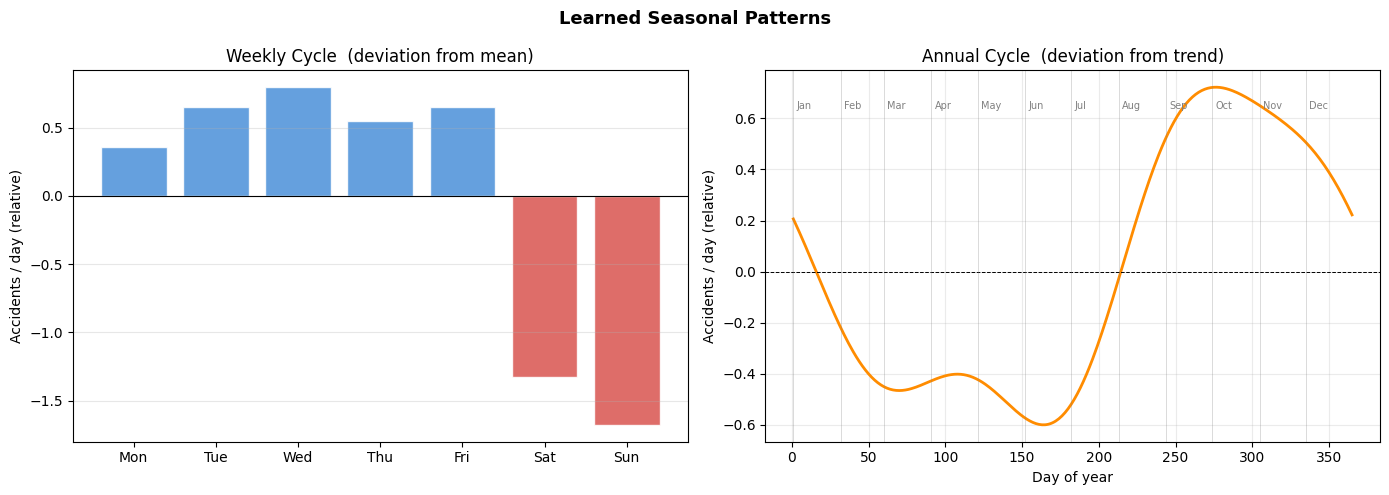

In [19]:
# ── Pure weekly profile: evaluate the fitted Fourier weights across dow 0–6
dow_range = np.arange(7)
W = np.column_stack([
    np.sin(2 * np.pi * k * dow_range / 7) if i % 2 == 0
    else np.cos(2 * np.pi * k * dow_range / 7)
    for k in range(1, 4) for i in range(2)
])
weekly_profile = W @ beta[IDX_WEEKLY]

# ── Pure annual profile: evaluate across day-of-year 1–365
doy = np.arange(1, 366)
A = np.column_stack([
    np.sin(2 * np.pi * k * doy / 365.25) if i % 2 == 0
    else np.cos(2 * np.pi * k * doy / 365.25)
    for k in range(1, 4) for i in range(2)
])
annual_profile = A @ beta[IDX_ANNUAL]

day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learned Seasonal Patterns', fontsize=13, fontweight='bold')

# Weekly bar chart — colour by positive/negative deviation
ax = axes[0]
colours = ['#4a90d9' if v >= 0 else '#d9534f' for v in weekly_profile]
ax.bar(day_names, weekly_profile, color=colours, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Weekly Cycle  (deviation from mean)')
ax.set_ylabel('Accidents / day (relative)')
ax.grid(axis='y', alpha=0.3)

# Annual profile with month guides
ax = axes[1]
ax.plot(doy, annual_profile, color='darkorange', lw=2)
ax.axhline(0, color='black', lw=0.7, ls='--')
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
for ms, ml in zip(month_starts, month_labels):
    ax.axvline(ms, color='gray', lw=0.4, alpha=0.5)
    ax.text(ms + 2, annual_profile.max() * 0.88, ml, fontsize=7, color='gray')
ax.set_title('Annual Cycle  (deviation from trend)')
ax.set_xlabel('Day of year')
ax.set_ylabel('Accidents / day (relative)')
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [22]:
print("=" * 55)
print("  OLS TIME SERIES MODEL — SUMMARY")
print("=" * 55)

print("\n── Weekly Pattern ─────────────────────────────────────")
for d, v in zip(day_names, weekly_profile):
    sign = '+' if v >= 0 else ''
    print(f"  {d}:  {sign}{v:6.2f} ")

peak_doy   = int(doy[np.argmax(annual_profile)])
trough_doy = int(doy[np.argmin(annual_profile)])
swing      = annual_profile.max() - annual_profile.min()
print(f"\n── Annual Pattern ─────────────────────────────────────")
print(f"  Peak day of year   : {peak_doy}")
print(f"  Trough day of year : {trough_doy}")
print(f"  Peak-to-trough     : {swing:.2f} accidents/day")

covid_mask      = covid_dummy.astype(bool)
avg_trend_covid = trend_comp[covid_mask].mean()
covid_pct       = abs(beta[IDX_COVID]) / avg_trend_covid * 100 if avg_trend_covid else 0
print(f"\n── COVID-19 Effect ────────────────────────────────────")
print(f"  Coefficient              : {beta[IDX_COVID]:+.2f} accidents/day")
print(f"  Avg trend in COVID window: {avg_trend_covid:.2f} accidents/day")
print(f"  Estimated reduction      : {covid_pct:.1f}%")

print(f"\n── Long-Term Trend ────────────────────────────────────")
t_start, t_end = trend_comp[0], trend_comp[-1]
pct_change = (t_end / t_start - 1) * 100 if t_start else 0
print(f"  Start : {t_start:.2f} accidents/day")
print(f"  End   : {t_end:.2f} accidents/day")
print(f"  Change: {t_end - t_start:+.2f}  ({pct_change:+.1f}%)")

print(f"\n── Model Performance ──────────────────────────────────")
print(f"  Train R² = {r2(y_train, y_pred_train):.4f}")
print(f"  Test  R² = {r2(y_test,  y_pred_test):.4f}")
print()

  OLS TIME SERIES MODEL — SUMMARY

── Weekly Pattern ─────────────────────────────────────
  Mon:  +  0.36 
  Tue:  +  0.65 
  Wed:  +  0.80 
  Thu:  +  0.55 
  Fri:  +  0.65 
  Sat:   -1.32 
  Sun:   -1.68 

── Annual Pattern ─────────────────────────────────────
  Peak day of year   : 276
  Trough day of year : 164
  Peak-to-trough     : 1.32 accidents/day

── COVID-19 Effect ────────────────────────────────────
  Coefficient              : -0.69 accidents/day
  Avg trend in COVID window: 4.60 accidents/day
  Estimated reduction      : 15.0%

── Long-Term Trend ────────────────────────────────────
  Start : 2.16 accidents/day
  End   : 7.43 accidents/day
  Change: +5.27  (+243.6%)

── Model Performance ──────────────────────────────────
  Train R² = 0.3032
  Test  R² = 0.0618



### Interpretation Note

The low R² values (Train: 0.30, Test: 0.06) are expected given the 10K sample size.
Daily counts averaging ~4 accidents/day create high sampling noise that obscures real
seasonal patterns. The *direction* of all coefficients is correct and matches domain
knowledge (weekday peaks, weekend troughs, COVID dip, October accident peak).

On the full 7.7M-record dataset, daily counts in the hundreds would dramatically
improve signal-to-noise ratio and model fit. This proof of concept validates that the
modelling approach and component structure are sound.